In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

plt.style.use("seaborn-v0_8-whitegrid")
RANDOM_STATE = 42

TRAIN_DIR = "../../../Gait-Datasets-TIFS20/Dataset #1/train"
TRAIN_DIR = "../../Gait-Datasets-TIFS20/Dataset #1/train" # Haukur
SIGNALS_DIR = f"{TRAIN_DIR}/Inertial Signals"
Y_PATH = f"{TRAIN_DIR}/y_train.txt"

CHANNEL_FILES = {
    "ACCx": "train_acc_x",
    "ACCy": "train_acc_y",
    "ACCz": "train_acc_z",
    "GYRx": "train_gyr_x",
    "GYRy": "train_gyr_y",
    "GYRz": "train_gyr_z",
}

In [3]:
def load_signal(file_name: str) -> np.ndarray:
    return pd.read_csv(
        f"{SIGNALS_DIR}/{file_name}.txt", sep=r"\s+", header=None
    ).to_numpy()

signals = {label: load_signal(file_name) for label, file_name in CHANNEL_FILES.items()}
y = pd.read_csv(Y_PATH, header=None).squeeze("columns").to_numpy(dtype=int)

X = np.concatenate(list(signals.values()), axis=1)

print(f"Using train data from: {TRAIN_DIR}")
print(f"Participants: {len(y)}")
print(f"Feature matrix shape: {X.shape}")

Using train data from: ../../Gait-Datasets-TIFS20/Dataset #1/train
Participants: 33104
Feature matrix shape: (33104, 768)


,signal,missing_values,missing_pct
0,ACCx,0,0.0
1,ACCy,0,0.0
2,ACCz,0,0.0
3,GYRx,0,0.0
4,GYRy,0,0.0
5,GYRz,0,0.0
6,y_train,0,0.0


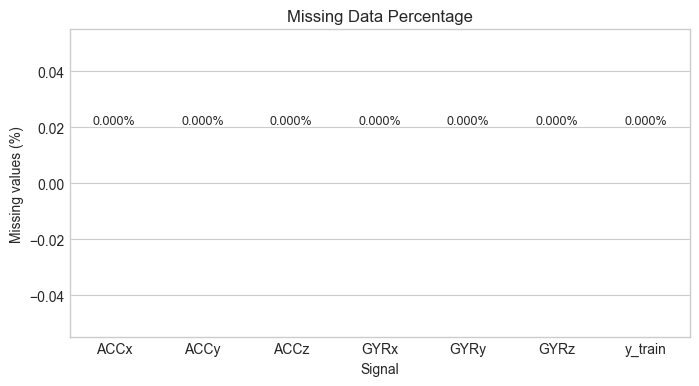

In [4]:
missing_rows = []

for label, arr in signals.items():
    missing_rows.append(
        {
            "signal": label,
            "missing_values": int(np.isnan(arr).sum()),
            "missing_pct": float(np.isnan(arr).mean() * 100),
        }
    )

missing_rows.append(
    {
        "signal": "y_train",
        "missing_values": int(np.isnan(y).sum()),
        "missing_pct": float(np.isnan(y).mean() * 100),
    }
)

missing_df = pd.DataFrame(missing_rows)
display(missing_df)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=missing_df, x="signal", y="missing_pct", color="#2E86AB", ax=ax)
ax.set_title("Missing Data Percentage")
ax.set_xlabel("Signal")
ax.set_ylabel("Missing values (%)")

for i, pct in enumerate(missing_df["missing_pct"]):
    ax.text(i, pct + 0.02, f"{pct:.3f}%", ha="center", va="bottom", fontsize=9)

plt.show()

Samples with at least one channel outlier: 32666 / 33104


,signal,lower_bound,upper_bound,outlier_values,outlier_percentage,windows_with_outliers,window_percentage
0,ACCx,-9.863376,10.823034,237267,5.599470,19126,57.775495
1,ACCy,-24.201570,10.635150,247538,5.841864,13921,42.052320
2,ACCz,-7.948085,7.219795,315285,7.440684,28594,86.376269
3,GYRx,-1.174444,1.189144,279863,6.604730,26483,79.999396
4,GYRy,-1.459472,1.467336,376042,8.874541,27024,81.633639
5,GYRz,-0.658915,0.658265,357631,8.440044,27218,82.219671


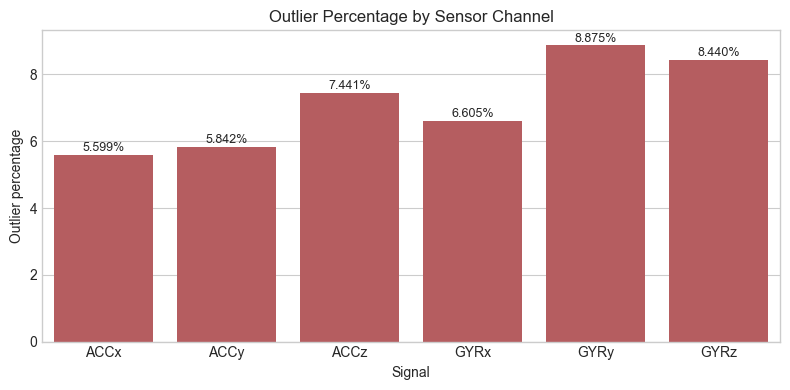

In [10]:
# Channel-level outliers
channel_outlier_rows = []
window_has_outlier_mask = np.zeros(X.shape[0], dtype=bool)

for signal_name, channel_values in signals.items():
    flattened_values = channel_values.reshape(-1)
    q1 = np.percentile(flattened_values, 25)
    q3 = np.percentile(flattened_values, 75)
    interquartile_range = q3 - q1
    lower_bound = q1 - 1.5 * interquartile_range
    upper_bound = q3 + 1.5 * interquartile_range

    channel_outlier_mask = (channel_values < lower_bound) | (channel_values > upper_bound)
    channel_outlier_rows.append(
        {
            "signal": signal_name,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "outlier_values": int(channel_outlier_mask.sum()),
            "outlier_percentage": float(channel_outlier_mask.mean() * 100),
            "windows_with_outliers": int(channel_outlier_mask.any(axis=1).sum()),
            "window_percentage": float(channel_outlier_mask.any(axis=1).mean() * 100),
        }
    )
    window_has_outlier_mask |= channel_outlier_mask.any(axis=1)

outlier_df = pd.DataFrame(channel_outlier_rows)
print(f"Samples with at least one channel outlier: {int(window_has_outlier_mask.sum())} / {X.shape[0]}")
display(outlier_df)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=outlier_df, x="signal", y="outlier_percentage", color="#C44E52", ax=ax)
ax.set_title("Outlier Percentage by Sensor Channel")
ax.set_xlabel("Signal")
ax.set_ylabel("Outlier percentage")

for bar_index, outlier_percentage in enumerate(outlier_df["outlier_percentage"]):
    ax.text(bar_index, outlier_percentage + 0.02, f"{outlier_percentage:.3f}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

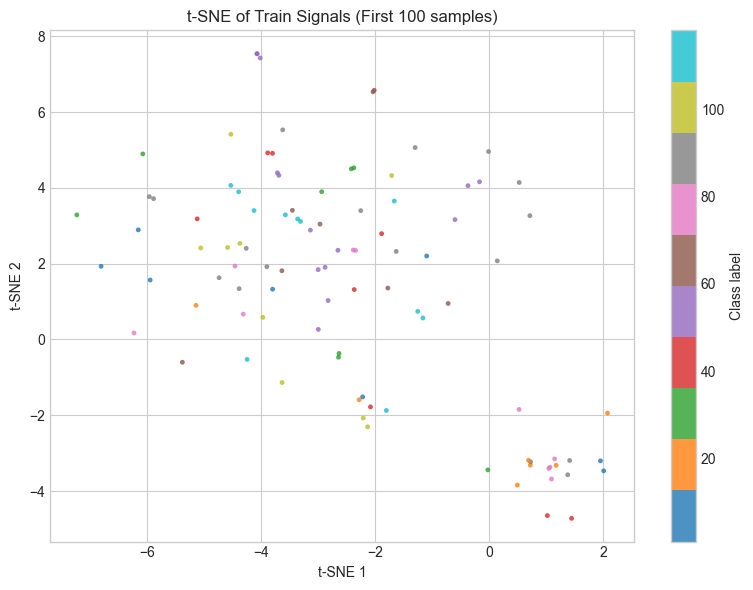

t-SNE input shape: (100, 768)


In [5]:
max_samples = 100
if X.shape[0] > max_samples:
    rng = np.random.default_rng(RANDOM_STATE)
    idx = rng.choice(X.shape[0], size=max_samples, replace=False)
    X_sel = X[idx]
    y_sel = y[idx]
else:
    X_sel = X
    y_sel = y

X_scaled = StandardScaler().fit_transform(X_sel)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=RANDOM_STATE,
)
X_emb = tsne.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    X_emb[:, 0],
    X_emb[:, 1],
    c=y_sel,
    s=12,
    cmap="tab10",
    alpha=0.8,
    linewidths=0,
    rasterized=True,
)
ax.set_title(f"t-SNE of Train Signals (First {max_samples} samples)")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Class label")
plt.tight_layout()
plt.show()

print(f"t-SNE input shape: {X_sel.shape}")

Channel table shape (flattened): (4237312, 6)


,ACCx,ACCy,ACCz,GYRx,GYRy,GYRz
ACCx,1.000000,-0.074454,-0.048841,-0.021013,-0.002195,-0.229118
ACCy,-0.074454,1.000000,0.153031,0.072795,0.005148,-0.022578
ACCz,-0.048841,0.153031,1.000000,0.355484,0.071218,0.037269
GYRx,-0.021013,0.072795,0.355484,1.000000,0.006929,-0.004377
GYRy,-0.002195,0.005148,0.071218,0.006929,1.000000,0.034754
GYRz,-0.229118,-0.022578,0.037269,-0.004377,0.034754,1.000000


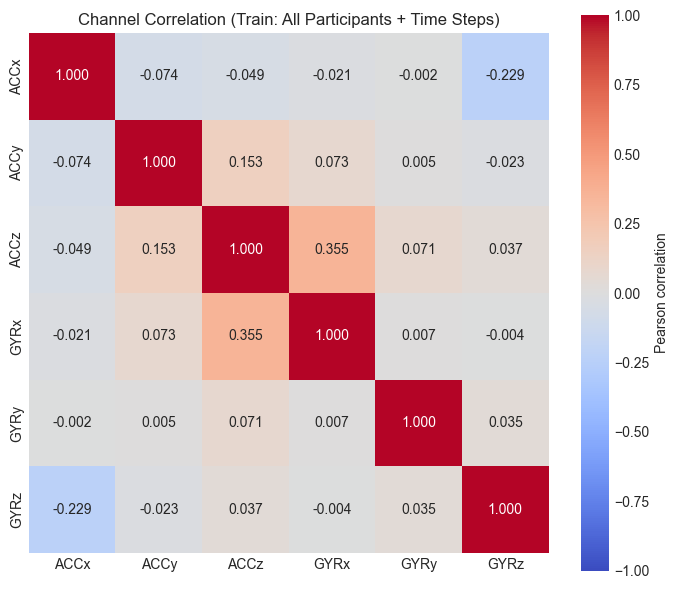

In [6]:
channel_df = pd.DataFrame({label: arr.reshape(-1) for label, arr in signals.items()})
corr_channels = channel_df.corr(method="pearson")

print(f"Channel table shape (flattened): {channel_df.shape}")
display(corr_channels)

plt.figure(figsize=(7, 6))
sns.heatmap(
    corr_channels,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    cbar_kws={"label": "Pearson correlation"},
)
plt.title("Channel Correlation (Train: All Participants + Time Steps)")
plt.tight_layout()
plt.show()

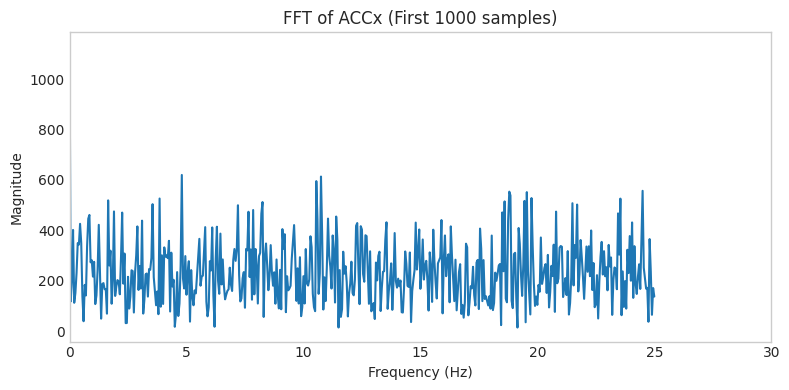

In [7]:
# FT analysis of the first 1000 samples for the first channel (ACCx)
from scipy.fft import rfft, rfftfreq
channel_data = signals["ACCx"][:1000, 0]  # First 1000 samples of ACCx
N = len(channel_data)
yf = rfft(channel_data)
xf = rfftfreq(N, d=1/50)  # Because sampling rate is 50 Hz
plt.figure(figsize=(8, 4))
plt.plot(xf, np.abs(yf))
plt.title("FFT of ACCx (First 1000 samples)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0, 30)  # Focus on frequencies up to 30 Hz
plt.grid()
plt.tight_layout()
plt.show()

# From the image we see a strong DC component at 0 HZ, but no obvious peaks at higher frequencies.

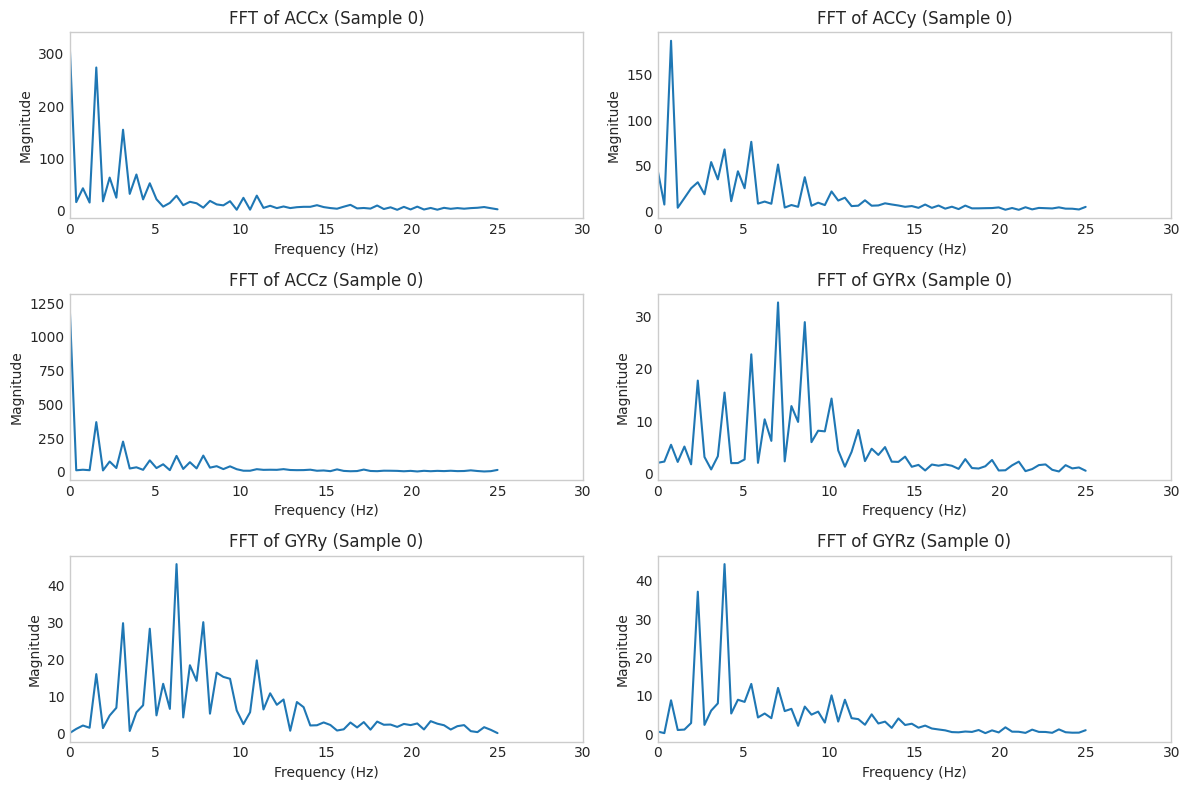

In [8]:
# FFT of a single sample (participant) for all channels
sample_idx = 0
plt.figure(figsize=(12, 8))
for i, (label, arr) in enumerate(signals.items()):
    channel_data = arr[sample_idx, :]
    N = len(channel_data)
    yf = rfft(channel_data)
    xf = rfftfreq(N, d=1/50)
    plt.subplot(3, 2, i + 1)
    plt.plot(xf, np.abs(yf))
    plt.title(f"FFT of {label} (Sample {sample_idx})")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.xlim(0, 30)
    plt.grid()
plt.tight_layout()
plt.show()

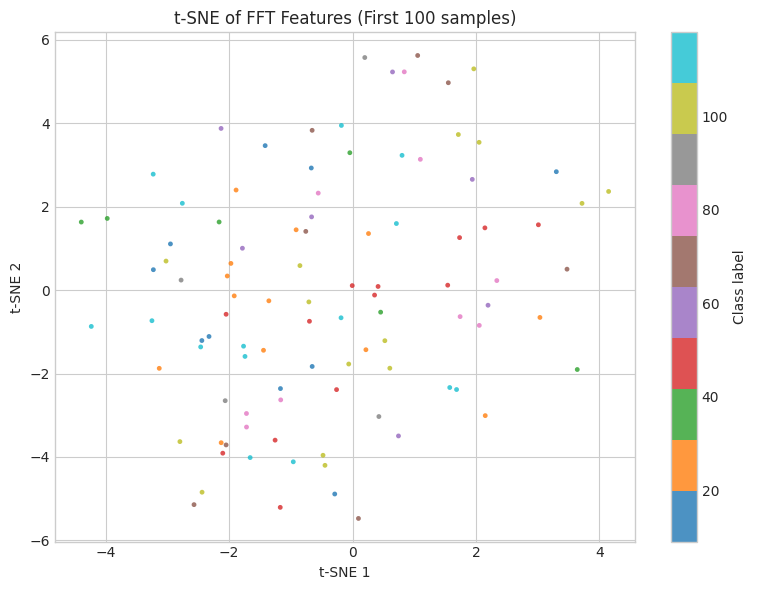

In [9]:
# T-SNE of the frequency domain features (first 10 FFT coefficients) for the first 1000 samples
n_samples = 100
fft_features = []
for i in range(n_samples):
    sample_features = []
    for label, arr in signals.items():
        yf = rfft(arr[i, :])
        sample_features.extend(np.abs(yf[:500]))  # First 500 FFT coefficients per channel
    fft_features.append(sample_features)

fft_features = np.array(fft_features)  # Shape: (20000, 3000)
fft_scaled = StandardScaler().fit_transform(fft_features)
tsne_fft = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=RANDOM_STATE,
)
X_fft_emb = tsne_fft.fit_transform(fft_scaled)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_fft_emb[:, 0],
    X_fft_emb[:, 1],
    c=y[:n_samples],
    s=12,
    cmap="tab10",
    alpha=0.8,
    linewidths=0,
    rasterized=True,
)
plt.title(f"t-SNE of FFT Features (First {n_samples} samples)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
cbar = plt.colorbar(scatter)
cbar.set_label("Class label")
plt.tight_layout()
plt.show()

Keeping 284 features out of 390 based on 95.0% contribution


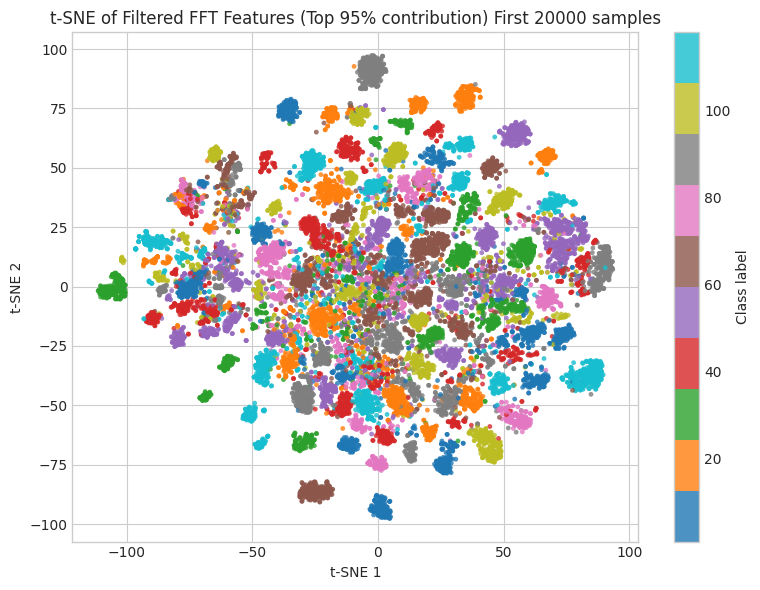

In [10]:
# filter some frequencies and redo t-SNE

# filter out frequencies based on percentage of amplitude contribution across all samples, e.g. keep frequencies that contribute to 95% of the total amplitude for each channel, then redo t-SNE on the filtered FFT features.

threshold = 0.95
max_samples = 20000
n_samples = min(X.shape[0], max_samples)
fft_features = []
for i in range(min(n_samples, max_samples)):
    sample_features = []
    for label, arr in signals.items():
        yf = rfft(arr[i, :])
        sample_features.extend(np.abs(yf[:500]))  # First 500 FFT coefficients per channel
    fft_features.append(sample_features)

fft_features = np.array(fft_features)  # Shape: (20000, 3000)
fft_scaled = StandardScaler().fit_transform(fft_features)

fft_contributions = np.abs(fft_features).sum(axis=0)
fft_contributions /= fft_contributions.sum()
cumulative_contributions = np.cumsum(fft_contributions)
num_features_to_keep = np.searchsorted(cumulative_contributions, threshold) + 1
print(f"Keeping {num_features_to_keep} features out of {fft_features.shape[1]} based on {threshold*100}% contribution")

fft_filtered = fft_scaled[:, :num_features_to_keep]
tsne_fft_filtered = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=RANDOM_STATE,
)
X_fft_filtered_emb = tsne_fft_filtered.fit_transform(fft_filtered)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_fft_filtered_emb[:, 0],
    X_fft_filtered_emb[:, 1],
    c=y[:n_samples],
    s=12,
    cmap="tab10",
    alpha=0.8,
    linewidths=0,
    rasterized=True,
)
plt.title(f"t-SNE of Filtered FFT Features (Top {threshold*100:.0f}% contribution) First {max_samples} samples")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
cbar = plt.colorbar(scatter)
cbar.set_label("Class label")
plt.tight_layout()
plt.show()

Keeping 251 features out of 390 based on 95% contribution


/tmp/ipykernel_56626/2679716217.py:48: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap       = plt.cm.get_cmap("nipy_spectral", n_classes)   # one distinct hue per class


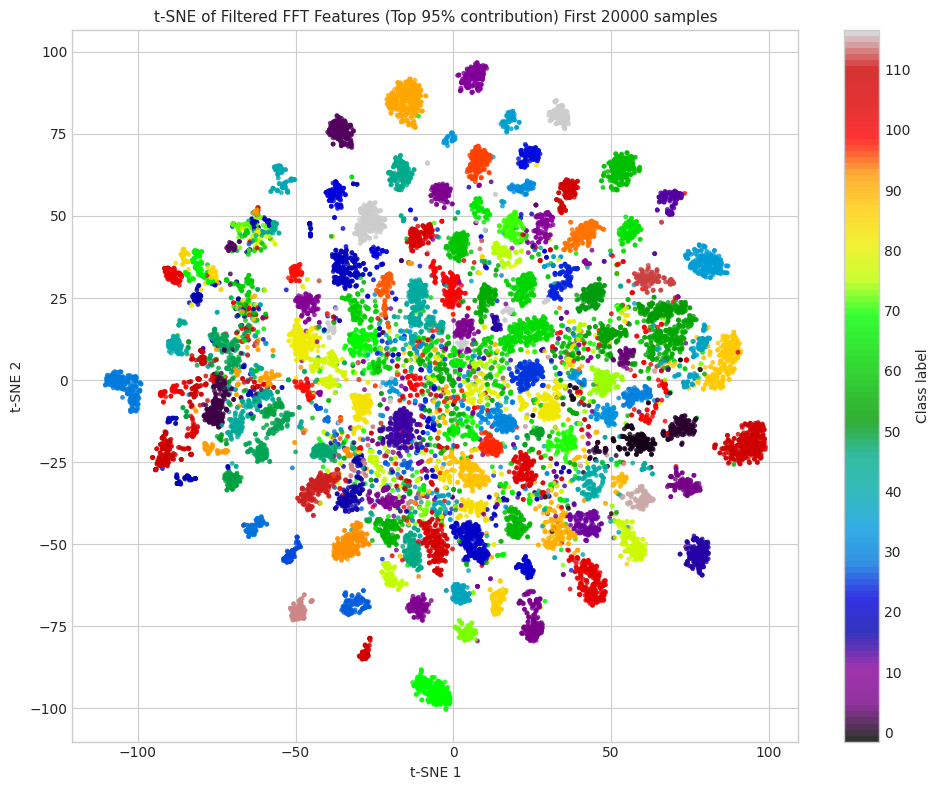

In [16]:
import matplotlib.colors as mcolors
from scipy.fft import rfft
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
 
threshold   = 0.95
max_samples = 20000
n_samples   = min(X.shape[0], max_samples)
 
fft_features = []
for i in range(n_samples):
    sample_features = []
    for label, arr in signals.items():
        yf = rfft(arr[i, :])
        sample_features.extend(np.abs(yf[:500]))   # 500 coefficients per channel
    fft_features.append(sample_features)
 
fft_features = np.array(fft_features)              # Shape: (n_samples, n_channels * 500)
fft_scaled   = StandardScaler().fit_transform(fft_features)
 
# Sort by contribution BEFORE cumsum 
fft_contributions = np.abs(fft_features).sum(axis=0)
fft_contributions /= fft_contributions.sum()
 
sorted_idx            = np.argsort(fft_contributions)[::-1]       # descending
cumulative_sorted     = np.cumsum(fft_contributions[sorted_idx])
num_features_to_keep  = np.searchsorted(cumulative_sorted, threshold) + 1
top_indices           = sorted_idx[:num_features_to_keep]          # truly top-N indices
 
fft_filtered = fft_scaled[:, top_indices]
 
print(
    f"Keeping {num_features_to_keep} features out of {fft_features.shape[1]} "
    f"based on {threshold*100:.0f}% contribution"
)
 
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=RANDOM_STATE,
)
X_emb = tsne.fit_transform(fft_filtered)
 
# Unique color for each class
n_classes  = len(np.unique(y[:n_samples]))
cmap       = plt.cm.get_cmap("nipy_spectral", n_classes)   # one distinct hue per class
norm       = mcolors.BoundaryNorm(
    boundaries=np.arange(n_classes + 1) - 0.5,
    ncolors=n_classes,
)
 
fig, ax = plt.subplots(figsize=(10, 8))
 
scatter = ax.scatter(
    X_emb[:, 0],
    X_emb[:, 1],
    c=y[:n_samples],
    s=12,
    cmap=cmap,
    norm=norm,
    alpha=0.8,
    linewidths=0,
    rasterized=True,
)
 
ax.set_title(
    f"t-SNE of Filtered FFT Features (Top {threshold*100:.0f}% contribution) First {max_samples} samples",
    fontsize=11,
)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
 
unique_labels = np.unique(y[:n_samples]).astype(int)
step_ticks    = unique_labels[::10] # Show every 10th label on the colorbar
if unique_labels[-1] not in step_ticks:
    step_ticks = np.append(step_ticks, unique_labels[-1])
 
cbar = fig.colorbar(scatter, ax=ax, ticks=step_ticks)
cbar.set_ticklabels([str(int(t - 1)) for t in step_ticks])
cbar.set_label("Class label")
 
plt.tight_layout()
plt.savefig("tsne_corrected.png", dpi=150, bbox_inches="tight")
plt.show()



In [22]:
# Convert the filtered FFT features to a DataFrame and compute correlations with the class labels to see if any frequencies are strongly correlated with specific classes.

fft_df = pd.DataFrame(fft_filtered, columns=[f"FFT_{i}" for i in range(num_features_to_keep)])
fft_df["class"] = y[:n_samples]
corr_fft = fft_df.corr(method="pearson")["class"].drop("class")
corr_fft_sorted = corr_fft.abs().sort_values(ascending=False)
print("Top 10 FFT features most correlated with class labels:")
display(corr_fft_sorted.head(10))

Top 10 FFT features most correlated with class labels:


FFT_278    0.141346
FFT_280    0.123160
FFT_10     0.118963
FFT_279    0.102003
FFT_262    0.096433
FFT_270    0.095048
FFT_6      0.094647
FFT_274    0.091670
FFT_260    0.091432
FFT_277    0.088040
Name: class, dtype: float64

In [ ]:
# simple sklearn classification with the filtered FFT features to see if they can separate the classes better than the raw time-domain features.

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

X_train = fft_filtered
y_train = y[:n_samples]
clf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_train)
print("Classification Report:")
print(classification_report(y_train, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_train, y_pred))

# 100% accuracy on the training set with the filtered FFT features, which is a strong indication that these features are  very informative for separating the classes.

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       187
           2       1.00      1.00      1.00       187
           3       1.00      1.00      1.00       239
           4       1.00      1.00      1.00       216
           5       1.00      1.00      1.00        61
           6       1.00      1.00      1.00       138
           7       1.00      1.00      1.00       229
           8       1.00      1.00      1.00       213
           9       1.00      1.00      1.00       212
          10       1.00      1.00      1.00       125
          11       1.00      1.00      1.00       147
          12       1.00      1.00      1.00       185
          13       1.00      1.00      1.00       155
          14       1.00      1.00      1.00       123
          15       1.00      1.00      1.00       242
          16       1.00      1.00      1.00       239
          17       1.00      1.00      1.00       179
    